In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from medmnist import ChestMNIST
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from torch.utils.data import Subset

torch.manual_seed(42)
np.random.seed(42)

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

train_dataset = ChestMNIST(split='train', download=True, size=64, transform=transform)
test_dataset  = ChestMNIST(split='test',  download=True, size=64, transform=transform)

indices_10k = torch.load('models/indices_10k.pth')
train_dataset = Subset(train_dataset, indices_10k)
test_dataset  = Subset(test_dataset,  range(3000))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          generator=torch.Generator().manual_seed(42))
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Data chargée | Device : {device}")

Data chargée | Device : cpu


In [3]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Encodeur
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 64x64
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 32x32
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 16x16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 16x16
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 8x8
        )
        
        # Décodeur
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),  # 16x16
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # 32x32
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),  # 64x64
            nn.Tanh()
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model_ae = Autoencoder().to(device)
print(model_ae)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(32, 1, kernel_size=(2, 2), stride=(2, 2))
    (5): Tanh()
  )
)


In [4]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model_ae.parameters(), lr=1e-3)

torch.manual_seed(42)
print("Setup ok ")

Setup ok 


In [5]:
def train_ae(model, train_loader, criterion, optimizer, epochs=6):
    train_losses = []
    best_loss = float('inf')
    patience = 3
    counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, imgs)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f}")

        if train_loss < best_loss:
            best_loss = train_loss
            torch.save(model.state_dict(), 'models/autoencoder_best.pth')
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping à l'epoch {epoch+1}")
                break

    model.load_state_dict(torch.load('models/autoencoder_best.pth', map_location=device))
    print("Meilleur modèle rechargé")
    return train_losses

train_losses = train_ae(model_ae, train_loader, criterion, optimizer, epochs=6)

Epoch [1/6] | Train Loss: 0.0321
Epoch [2/6] | Train Loss: 0.0075
Epoch [3/6] | Train Loss: 0.0059
Epoch [4/6] | Train Loss: 0.0052
Epoch [5/6] | Train Loss: 0.0047
Epoch [6/6] | Train Loss: 0.0044
Meilleur modèle rechargé


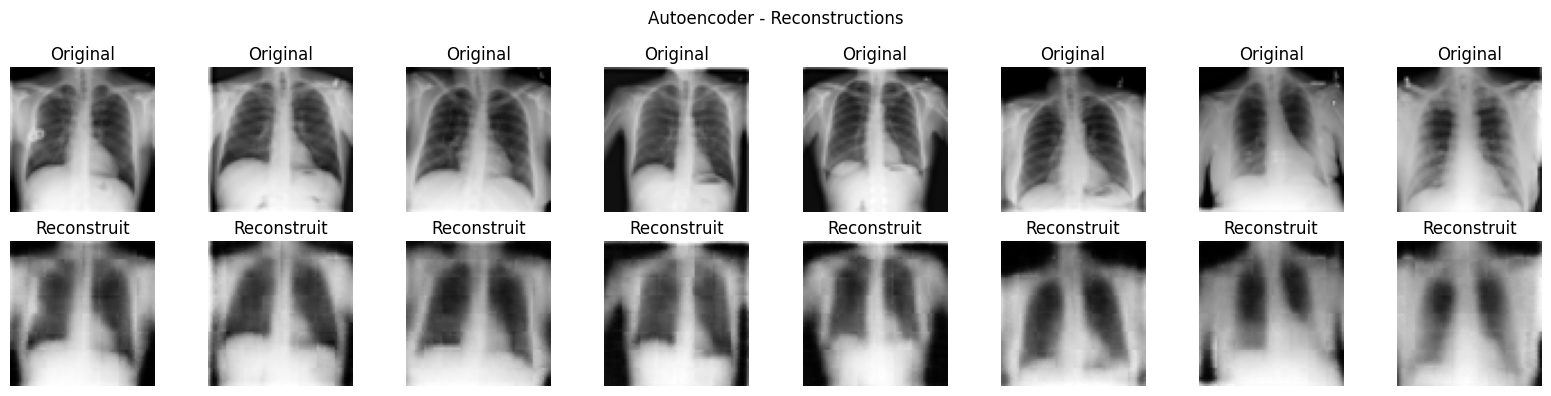

In [6]:
model_ae.eval()
with torch.no_grad():
    imgs, _ = next(iter(test_loader))
    imgs = imgs.to(device)
    outputs = model_ae(imgs)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    # Original
    axes[0, i].imshow(imgs[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title('Original')
    
    # Reconstruction
    axes[1, i].imshow(outputs[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title('Reconstruit')

plt.suptitle("Autoencoder - Reconstructions")
plt.tight_layout()
plt.show()

Erreur moyenne     : 0.0042
Seuil d'anomalie   : 0.0081
Images atypiques   : 91 / 3000


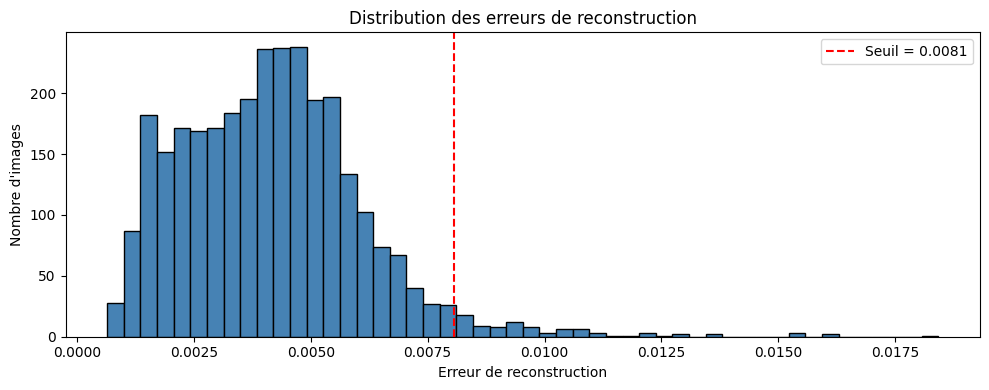

In [7]:
model_ae.eval()
reconstruction_errors = []

with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        outputs = model_ae(imgs)
        errors = ((imgs - outputs) ** 2).mean(dim=[1, 2, 3])
        reconstruction_errors.extend(errors.cpu().numpy())

reconstruction_errors = np.array(reconstruction_errors)

# Seuil = moyenne + 2 * écart-type
threshold = reconstruction_errors.mean() + 2 * reconstruction_errors.std()
anomalies = reconstruction_errors > threshold

print(f"Erreur moyenne     : {reconstruction_errors.mean():.4f}")
print(f"Seuil d'anomalie   : {threshold:.4f}")
print(f"Images atypiques   : {anomalies.sum()} / {len(anomalies)}")

plt.figure(figsize=(10, 4))
plt.hist(reconstruction_errors, bins=50, color='steelblue', edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', label=f'Seuil = {threshold:.4f}')
plt.title("Distribution des erreurs de reconstruction")
plt.xlabel("Erreur de reconstruction")
plt.ylabel("Nombre d'images")
plt.legend()
plt.tight_layout()
plt.show()

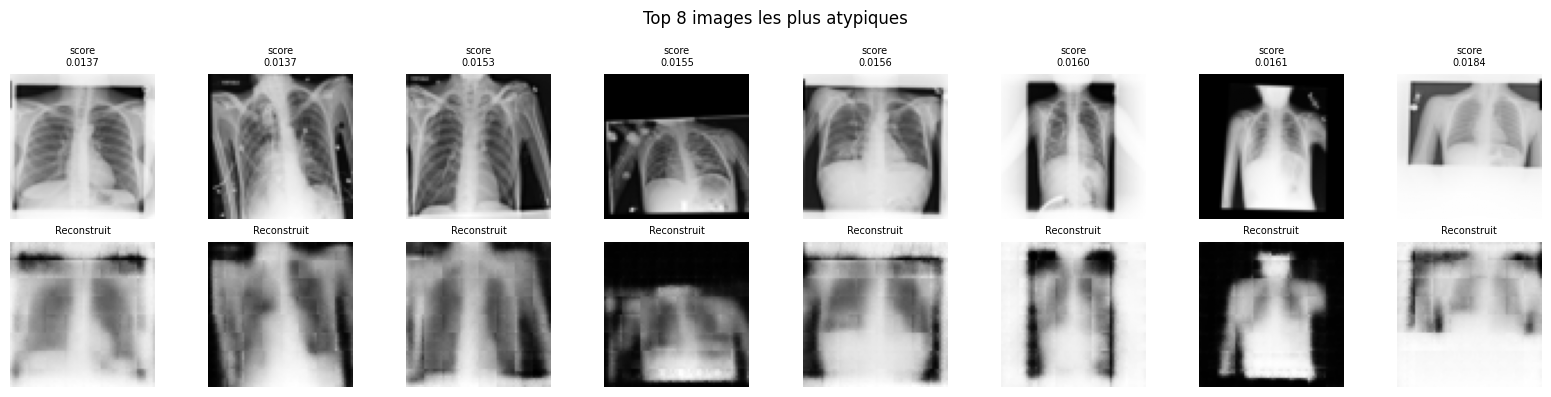

Modèle sauvegardé 


In [8]:
top_anomaly_idx = np.argsort(reconstruction_errors)[-8:]

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, idx in enumerate(top_anomaly_idx):
    img, _ = test_dataset[idx]
    img_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model_ae(img_tensor)

    axes[0, i].imshow(img_tensor.cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'score\n{reconstruction_errors[idx]:.4f}', fontsize=7)
    axes[0, i].axis('off')

    axes[1, i].imshow(output.cpu().squeeze(), cmap='gray')
    axes[1, i].set_title('Reconstruit', fontsize=7)
    axes[1, i].axis('off')

plt.suptitle("Top 8 images les plus atypiques")
plt.tight_layout()
plt.show()

torch.save(model_ae.state_dict(), 'models/autoencoder.pth')
print("Modèle sauvegardé ")